In [1]:
# 데이터 분석 
import pandas as pd
import numpy as np

# 데이터 시각화 분석 라이브러리 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 데이터 임포트 ( iris )
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split 

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report 

In [3]:
iris = load_iris()

In [4]:
X = iris.data 
y = iris.target

In [5]:
df = pd.DataFrame(X,columns= iris.feature_names )

In [6]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [7]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [8]:
# target 컬럼 추가  - 데이터 프레임 확인용 

df['target'] = y

df['species'] = df['target'].map({
    0 : 'setosa',
    1 : 'versicolor',
    2 : 'virginica'})

In [9]:
X = df[iris.feature_names]
y = df['target']

In [10]:
X_train , X_test , y_train , y_test = train_test_split(
    X , y,
    test_size = 0.2 , # 8 : 2  
    random_state = 42 , # 실행할 때마다 같은 결과가 나오도록 기준 유지 
    stratify = y ) # 품종 비율을 train/test 데이터에 거의 일정하게 유지 

### Random Forset 모델 생성 및 학습 

In [11]:
model = RandomForestClassifier(
    n_estimators=100, # Decision tree 100개 생성 
    max_depth=None, # 트리 최대 깊이 제한 X => Overfitting ( 과대적합 위험 증가 )
    # 하이퍼 파라미터 튜닝을 통하여 깊이 조정 
    # 과대 적합 ( Overfitting ) : 
    # 과소 적합 ( Underfitting ) : 
    random_state= 42 # 기준점 통일
)

In [12]:
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 모델 Prediction

In [13]:
y_pred = model.predict(X_test)
y_pred

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 1, 0, 2,
       1, 1, 2, 2, 1, 0, 2, 0])

### 모델 정확도 

In [14]:
accuracy = accuracy_score(y_test ,y_pred ) # 정확도 평가 
print("Random Forest 정확도 :" ,round(accuracy,4))

Random Forest 정확도 : 0.9


In [15]:
accuracy

0.9

In [16]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

### 모델 평가

### 혼동 행렬

In [17]:
# Confusion_Matrix  평가 
# y_test : 실제 정답 
# y_pred : 모델 예측값

cm = confusion_matrix(y_test , y_pred)
cm_df = pd.DataFrame(
    cm,
    index = ['실제 setosa','실제 versicolor','실제 virginica'],
    columns = ['예측 setosa','예측 versicolor','예측 virginica']
)
cm_df

,예측 setosa,예측 versicolor,예측 virginica
실제 setosa,10,0,0
실제 versicolor,0,9,1
실제 virginica,0,2,8


### Classification Report

In [18]:
print(classification_report(
    y_test,
    y_pred,
    target_names = iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



### Feature Importance 분석

In [19]:
importance = pd.DataFrame({
    'feature': iris.feature_names,
    'importance' : model.feature_importances_}) 

# sklearn에서 모델 학습 이후 생기는 값 뒤에는 _ 처리하는 경향이 존재함.

importance = importance.sort_values(
    by = 'importance',
    ascending = True # 내림차순 
)

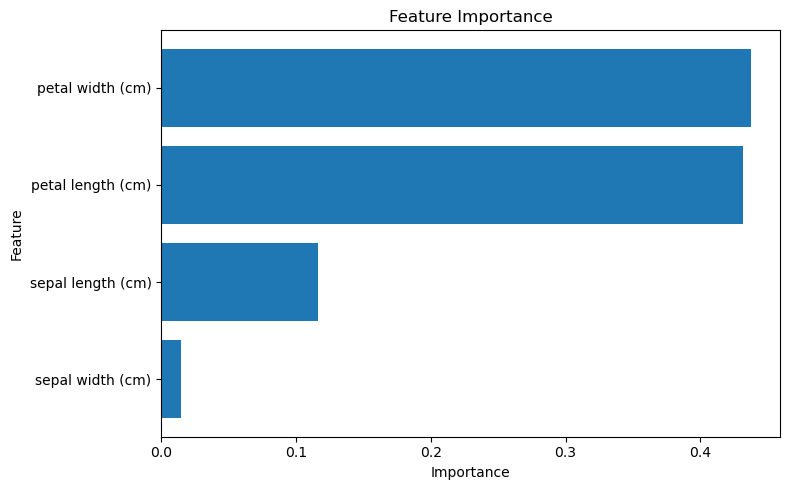

In [20]:
plt.figure(figsize=(8,5))

plt.barh(
    importance['feature'],
    importance['importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')

# plt.gca().invert_yaxis() # 현재의 그래프 Y축을 뒤집기
plt.tight_layout()
plt.show()

### 새로운 데이터를 가져다가 학습과 훈련된 모델을 바탕으로 품종 예측

In [21]:
X_test.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
38,4.4,3.0,1.3,0.2
127,6.1,3.0,4.9,1.8
57,4.9,2.4,3.3,1.0
93,5.0,2.3,3.3,1.0
42,4.4,3.2,1.3,0.2


In [22]:
y_pred

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 1, 0, 2,
       1, 1, 2, 2, 1, 0, 2, 0])

In [23]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [30]:
new_data = pd.DataFrame(
    [[5.1,3.5,1.4,0.2]],
    columns = iris.feature_names
)

pred = model.predict(new_data)

print("예측 숫자 : " ,pred[0])
print("예측 품종 : " ,iris.target_names[pred[0]])

예측 숫자 :  0
예측 품종 :  setosa


In [40]:
u_sepal_length = float(input("꽃받침의 길이 : "))
u_sepal_width = float(input("꽃받침의 너비 : "))
u_petal_length = float(input("꽃잎의 길이 : "))
u_petal_width = float(input("꽃잎의 너비 : "))

User_data = pd.DataFrame([
    [u_sepal_length,u_sepal_width,u_petal_length,u_petal_width]],
    columns = iris.feature_names
)

u_pred = model.predict(User_data)
# result = df[df['target']==u_pred[0]]['species'].unique()
# df 면에서 풀이
result = iris.target_names[u_pred[0]]
print(f"예측된 품종은 {result} 입니다")

꽃받침의 길이 :  4.4
꽃받침의 너비 :  3.3
꽃잎의 길이 :  2.2
꽃잎의 너비 :  1.1


예측된 품종은 setosa 입니다


In [32]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [33]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [28]:
y_test.head()

38     0
127    2
57     1
93     1
42     0
Name: target, dtype: int64

In [36]:
iris.target_names[u_pred[0]]

np.str_('setosa')

In [37]:
u_pred[0]

np.int64(0)

In [27]:
result

array(['setosa'], dtype=object)